In [1]:
# VADER Sentiment Analysis with GridSearch, Evaluation, and Visualization

In [2]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import joblib

In [3]:
nltk.download('vader_lexicon')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
def classify_sentiment(text):
    if not isinstance(text, str):
        text = ""
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

In [5]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    return [word for word in words if word not in stop_words]

In [6]:
def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])
    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

In [7]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Neutral', 'Positive'], yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [8]:
# Load and label datasets
#train_df = pd.read_csv('train_dataset.csv')
#test_df = pd.read_csv('test_dataset.csv')
train_df = pd.read_csv('train_dataset-test.csv')
test_df = pd.read_csv('test_dataset-test.csv')

In [9]:
train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)
test_df['Final_Comment'] = test_df['Final_Comment'].astype(str)

In [10]:
train_df['Sentiment'] = train_df['Final_Comment'].apply(classify_sentiment)
test_df['Sentiment'] = test_df['Final_Comment'].apply(classify_sentiment)

In [11]:
#train_df.to_csv('train_dataset_sentiment_vader.csv', index=False)
#test_df.to_csv('test_dataset_sentiment_vader.csv', index=False)
train_df.to_csv('train_dataset_sentiment_vader-test.csv', index=False)
test_df.to_csv('test_dataset_sentiment_vader-test.csv', index=False)

In [12]:
sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
train_df['Sentiment_Label'] = train_df['Sentiment'].map(sentiment_mapping)
test_df['Sentiment_Label'] = test_df['Sentiment'].map(sentiment_mapping)

In [13]:
train_df.dropna(subset=['Sentiment_Label'], inplace=True)
test_df.dropna(subset=['Sentiment_Label'], inplace=True)

In [14]:
train_df['Sentiment_Label'] = train_df['Sentiment_Label'].astype(int)
test_df['Sentiment_Label'] = test_df['Sentiment_Label'].astype(int)

In [15]:
# Train-test split for grid search
X = train_df['Final_Comment']
y = train_df['Sentiment_Label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('nb', ComplementNB())
])

In [17]:
param_grid = {
    'tfidf__max_df': [0.8, 1.0],
    'tfidf__min_df': [1, 5],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'nb__alpha': [0.1, 0.5, 1.0]
}

In [18]:
grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1_macro', verbose=2, n_jobs=-1)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('nb', ComplementNB())]),
             n_jobs=-1,
             param_grid={'nb__alpha': [0.1, 0.5, 1.0],
                         'tfidf__max_df': [0.8, 1.0], 'tfidf__min_df': [1, 5],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='f1_macro', verbose=2)

In [19]:
print("Best Parameters:", grid.best_params_)
print("Validation F1 Score:", grid.best_score_)

Best Parameters: {'nb__alpha': 1.0, 'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}
Validation F1 Score: 0.8039339882142607


In [20]:
# Final test evaluation
X_test = test_df['Final_Comment']
y_test = test_df['Sentiment_Label']
y_pred = grid.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Final Model Accuracy on Test Data: {accuracy * 100:.2f}%")


✅ Final Model Accuracy on Test Data: 83.27%


In [21]:
report = classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"], output_dict=True)
print("\n🧾 Classification Report (Text Version):")
print(classification_report(y_test, y_pred, target_names=["Negative", "Neutral", "Positive"]))


🧾 Classification Report (Text Version):
              precision    recall  f1-score   support

    Negative       0.77      0.82      0.80       314
     Neutral       0.89      0.80      0.84       818
    Positive       0.80      0.89      0.84       577

    accuracy                           0.83      1709
   macro avg       0.82      0.84      0.83      1709
weighted avg       0.84      0.83      0.83      1709



In [22]:
with open("classification_report_vader_test.json", "w") as f:
    json.dump(report, f, indent=2)

C:\Users\amirb\AppData\Local\Temp\ipykernel_3652\1643147463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


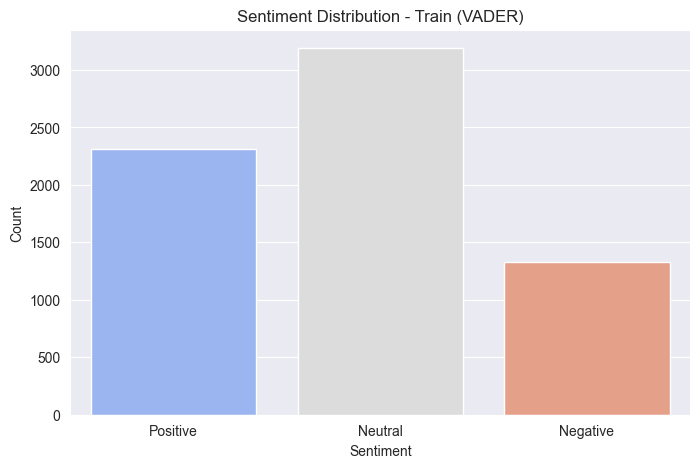

C:\Users\amirb\AppData\Local\Temp\ipykernel_3652\1643147463.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Sentiment'], palette='coolwarm', order=['Positive', 'Neutral', 'Negative'])


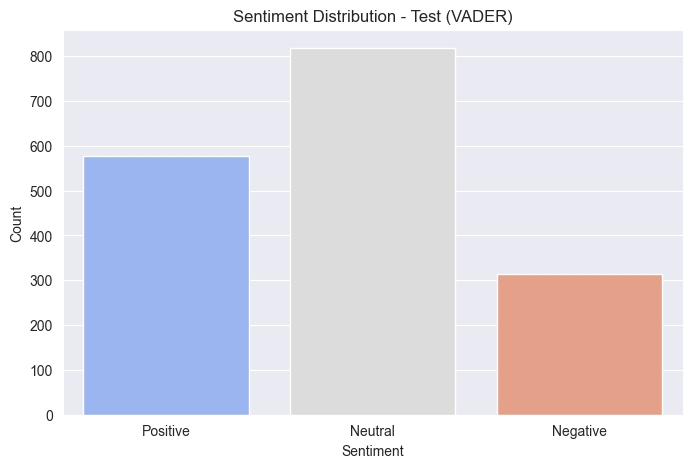

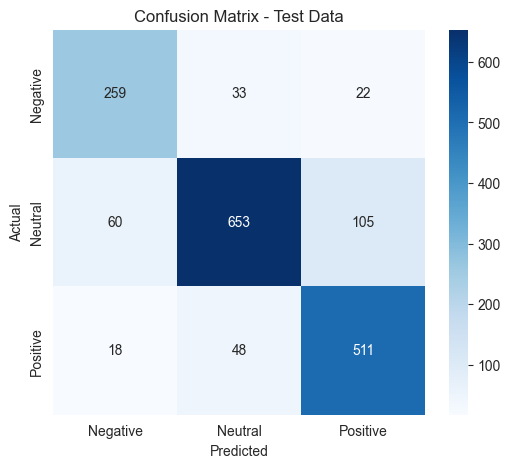

In [23]:
plot_sentiment_distribution(train_df, "Sentiment Distribution - Train (VADER)")
plot_sentiment_distribution(test_df, "Sentiment Distribution - Test (VADER)")
plot_confusion_matrix(y_test, y_pred, "Confusion Matrix - Test Data")

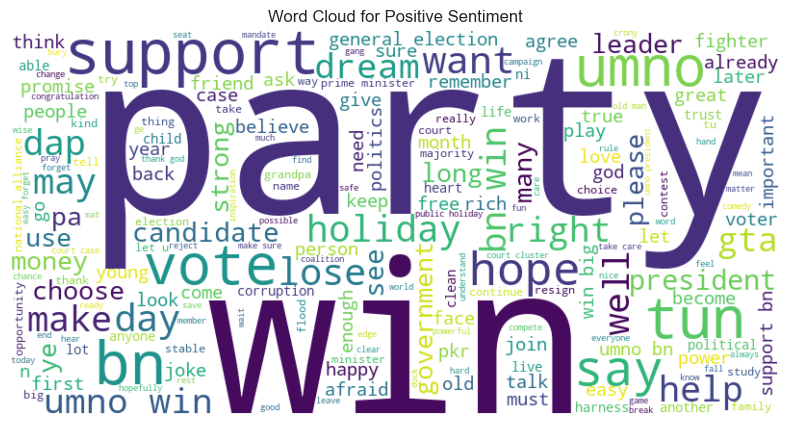

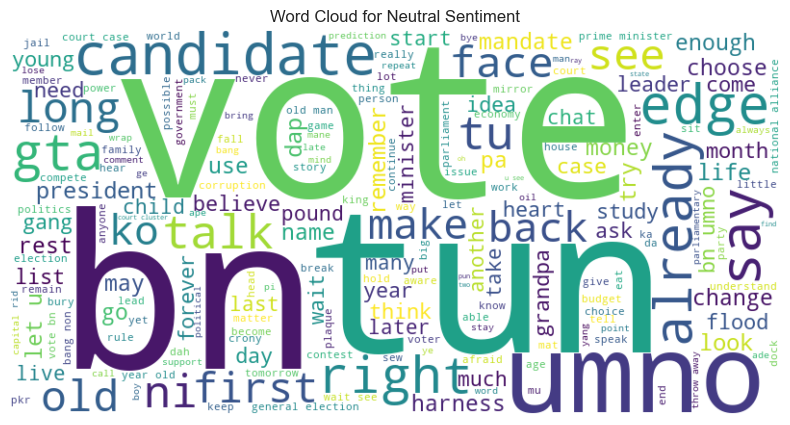

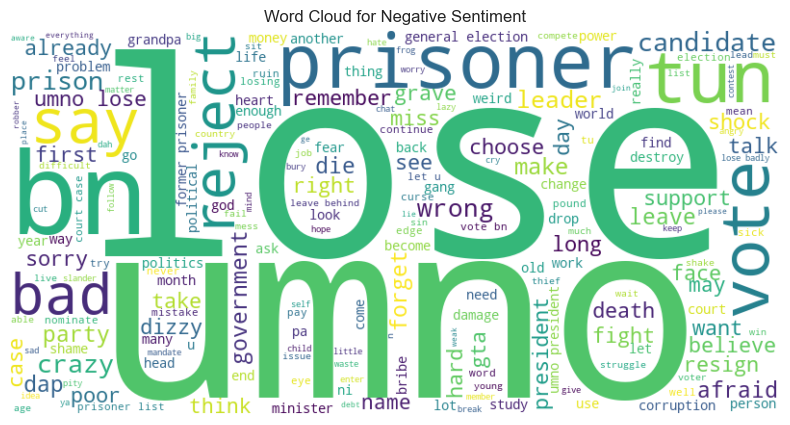

In [24]:
# Word clouds
for sentiment in ["Positive", "Neutral", "Negative"]:
    words = train_df[train_df['Sentiment'] == sentiment]['Final_Comment'].apply(preprocess_text).sum()
    text = ' '.join(words)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for {sentiment} Sentiment")
    plt.show()


Feature importance
feature_names = grid.best_estimator_.named_steps['tfidf'].get_feature_names_out()
log_probs = grid.best_estimator_.named_steps['nb'].feature_log_prob_

for i, label in enumerate(["Negative", "Neutral", "Positive"]):
    top_features = sorted(zip(log_probs[i], feature_names), reverse=True)[:10]
    words, scores = zip(*top_features)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(scores), y=list(words), palette='coolwarm')
    plt.title(f"Top Words for {label} Sentiment")
    plt.xlabel("Log Probability")
    plt.ylabel("Words")
    plt.show()

In [25]:
#joblib.dump(grid.best_estimator_, 'complementnb_model_vader.joblib')
joblib.dump(grid.best_estimator_, 'complementnb_model_vader-test.joblib')
print("✅ VADER-based GridSearch model saved.")

✅ VADER-based GridSearch model saved.
